# 👁️ MediaPipe 랜드마크 기반 시선 추적 모델 학습
## 루게릭병(ALS) 환우분들을 위한 경량 시선 추적

---

### 📌 전체 흐름
```
원천 데이터 (얼굴 사진)
       ↓  MediaPipe Face Mesh로 얼굴 랜드마크 추출
  랜드마크 좌표 (x, y, z) × 58개 = 174개 숫자
       ↓
라벨링 데이터 (JSON) → pitch(위아래), yaw(좌우) 각도
       ↓
  가벼운 MLP 모델 학습 (이미지 대신 좌표 입력)
       ↓
  MLflow로 학습 기록 → ONNX 내보내기 → 브라우저 배포
```

### 💡 왜 랜드마크 방식인가?
| 항목 | 이미지 기반 (ResNet50) | 랜드마크 기반 (이 노트북) |
|------|----------------------|---------------------------|
| 입력 크기 | 224×224×3 = 150,528 | 58×3 = 174 |
| 모델 크기 | ~90MB | ~1MB 이하 |
| 브라우저 실행 | 어려움 | ✅ ONNX.js로 바로 실행 |
| 학습 속도 | 느림 | ✅ 매우 빠름 |

## 0. 라이브러리 설치 (처음 한 번만)

In [1]:
# # 처음 실행할 때만 주석 해제하고 실행하세요
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121  # GPU
# !pip install mediapipe mlflow scikit-learn tqdm matplotlib numpy pillow

## 1. 라이브러리 불러오기

In [2]:
import os
import json
import math
import random
import pickle
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import mediapipe as mp
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import mlflow
import mlflow.pytorch

print(f"PyTorch 버전: {torch.__version__}")
print(f"MediaPipe 버전: {mp.__version__}")
print(f"GPU 사용 가능: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"학습 장치: {device}")
if torch.cuda.is_available():
    print(f"GPU 이름: {torch.cuda.get_device_name(0)}")

PyTorch 버전: 2.5.1+cu121
MediaPipe 버전: 0.10.32
GPU 사용 가능: True
학습 장치: cuda
GPU 이름: NVIDIA GeForce RTX 4070 Laptop GPU


## 2. ⚙️ 설정 (여기서만 수치를 바꾸면 됩니다)

In [3]:
# ────────────────────────────────────────────────────────────────
#  📂 경로 설정
# ────────────────────────────────────────────────────────────────
BASE_DIR   = Path(".")                                              # 현재 폴더 (landmark_gaze)
IMAGE_DIR  = BASE_DIR / ".." / "L2CS-Net" / "Data" / "raw_data"   # 원천 이미지
LABEL_DIR  = IMAGE_DIR / "label_data" / "json_rgb"                 # JSON 라벨
MP_MODEL   = BASE_DIR / "face_landmarker.task"                     # MediaPipe 모델 (같은 폴더)
CACHE_FILE = BASE_DIR / "landmark_cache.pkl"                       # 랜드마크 캐시 파일

# ────────────────────────────────────────────────────────────────
#  🏋️ 학습 하이퍼파라미터
# ────────────────────────────────────────────────────────────────
HIDDEN_DIMS   = [512, 256, 128]  # MLP 은닉층 크기 (조정 가능)
DROPOUT       = 0.3              # 드롭아웃 비율 (과적합 방지)
BATCH_SIZE    = 32               # 배치 크기
NUM_EPOCHS    = 200              # 학습 에포크 수 (랜드마크 입력이라 빠름)
LEARNING_RATE = 3e-4             # 학습률
WEIGHT_DECAY  = 1e-4             # 가중치 감소 (L2 정규화)
TRAIN_RATIO   = 0.8              # 학습:검증 비율
RANDOM_SEED   = 42               # 재현성을 위한 시드

# ────────────────────────────────────────────────────────────────
#  📁 이번 실행 전용 폴더 (실행할 때마다 새 폴더 생성)
#  형식: runs/run_001_날짜시간_ep200/
# ────────────────────────────────────────────────────────────────

# 기존 run 폴더 수를 세어서 차수 번호 결정
runs_dir = BASE_DIR / "runs"
runs_dir.mkdir(exist_ok=True)
existing_runs = [d for d in runs_dir.iterdir() if d.is_dir() and d.name.startswith("run_")]
run_num = len(existing_runs) + 1

RUN_NAME = f"run_{run_num:03d}_{datetime.now().strftime('%Y%m%d_%H%M')}_ep{NUM_EPOCHS}"
SAVE_DIR = runs_dir / RUN_NAME
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# 시드 고정 (결과 재현성)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print(f"이번 실행 이름: {RUN_NAME}")
print(f"저장 폴더: {SAVE_DIR}")
print(f"이미지 폴더 존재: {IMAGE_DIR.resolve().exists()}")
print(f"라벨 폴더 존재:   {LABEL_DIR.resolve().exists()}")
print(f"\n📂 폴더 구조:")
print(f"  runs/")
for d in sorted(runs_dir.iterdir()):
    marker = "← 이번 실행" if d.name == RUN_NAME else ""
    print(f"  ├── {d.name}/  {marker}")

이번 실행 이름: run_003_20260305_0623_ep200
저장 폴더: runs\run_003_20260305_0623_ep200
이미지 폴더 존재: True
라벨 폴더 존재:   True

📂 폴더 구조:
  runs/
  ├── run_001_20260305_0620_ep200/  
  ├── run_002_20260305_0622_ep200/  
  ├── run_003_20260305_0623_ep200/  ← 이번 실행


## 3. 🔍 사용할 랜드마크 정의

MediaPipe Face Mesh는 얼굴에서 478개 특징점을 뽑아줍니다.  
그 중 **시선 추정에 핵심적인 58개**만 골라서 사용합니다.

```
왼쪽 눈 윤곽 (16개)
오른쪽 눈 윤곽 (16개)
왼쪽 홍채 (5개)   ← 동공 위치가 시선 추정의 핵심!
오른쪽 홍채 (5개)
코 (8개)          ← 머리 방향 기준점
얼굴 윤곽 (8개)   ← 크기 정규화에 사용
━━━━━━━━━━━━━━━━━━
합계: 58개 × 3(x,y,z) = 174개 숫자 → 모델 입력
```

In [4]:
# 시선 추정에 중요한 랜드마크 인덱스
# (MediaPipe Face Mesh의 478개 중 선별)
LANDMARK_GROUPS = {
    'left_eye':     [33, 7, 163, 144, 145, 153, 154, 155, 133, 173, 157, 158, 159, 160, 161, 246],
    'right_eye':    [362, 382, 381, 380, 374, 373, 390, 249, 263, 466, 388, 387, 386, 385, 384, 398],
    'left_iris':    [468, 469, 470, 471, 472],   # 왼쪽 홍채 (동공 중심 포함)
    'right_iris':   [473, 474, 475, 476, 477],   # 오른쪽 홍채
    'nose':         [1, 2, 4, 6, 168, 197, 195, 5],  # 코 기준점
    'face_outline': [10, 152, 234, 454, 323, 93, 356, 127],  # 얼굴 윤곽 (크기 기준)
}

# 전체 선택 인덱스 리스트 (순서 중요 - 항상 같은 순서로 추출)
ALL_LANDMARK_IDX = []
for group_indices in LANDMARK_GROUPS.values():
    ALL_LANDMARK_IDX.extend(group_indices)

INPUT_DIM = len(ALL_LANDMARK_IDX) * 3  # 58개 × (x, y, z) = 174

# 정규화 기준점 인덱스 (선택된 랜드마크 중 코 끝의 위치)
NOSE_TIP_IDX  = ALL_LANDMARK_IDX.index(4)   # 코 끝 (랜드마크 4번)
L_IRIS_CTR    = ALL_LANDMARK_IDX.index(468)  # 왼쪽 홍채 중심
R_IRIS_CTR    = ALL_LANDMARK_IDX.index(473)  # 오른쪽 홍채 중심

print(f"총 선택 랜드마크: {len(ALL_LANDMARK_IDX)}개")
print(f"모델 입력 크기: {INPUT_DIM} (= {len(ALL_LANDMARK_IDX)} × 3)")
print()
for group_name, indices in LANDMARK_GROUPS.items():
    print(f"  {group_name:15s}: {len(indices)}개")

총 선택 랜드마크: 58개
모델 입력 크기: 174 (= 58 × 3)

  left_eye       : 16개
  right_eye      : 16개
  left_iris      : 5개
  right_iris     : 5개
  nose           : 8개
  face_outline   : 8개


## 4. 🤖 MediaPipe 설정 + 랜드마크 추출 함수

In [5]:
# ── MediaPipe FaceLandmarker 초기화 (Tasks API, mediapipe 0.10+) ──
BaseOptions          = mp.tasks.BaseOptions
FaceLandmarker       = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode    = mp.tasks.vision.RunningMode

mp_options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=str(MP_MODEL)),
    running_mode=VisionRunningMode.IMAGE,  # 이미지 파일 처리용 (VIDEO 아님)
    num_faces=1,
    min_face_detection_confidence=0.3,     # 낮게 설정해서 더 많은 얼굴 감지
    min_face_presence_confidence=0.3,
    min_tracking_confidence=0.3,
)

print(f"MediaPipe 모델 경로: {MP_MODEL.resolve()}")
print(f"모델 파일 존재: {MP_MODEL.exists()}")


def extract_landmarks(image_path, face_landmarker):
    """
    이미지에서 MediaPipe로 랜드마크를 추출하고 정규화합니다.
    
    반환: numpy 배열 [174] (58개 랜드마크 × x,y,z)
          얼굴을 감지하지 못하면 None 반환
    """
    # 이미지 읽기
    img = mp.Image.create_from_file(str(image_path))
    
    # MediaPipe로 랜드마크 감지
    result = face_landmarker.detect(img)
    
    # 얼굴을 못 찾으면 None 반환
    if not result.face_landmarks:
        return None
    
    # 첫 번째 얼굴의 랜드마크 (478개)
    lm = result.face_landmarks[0]
    
    # 선택한 58개 랜드마크만 추출 → [58, 3] 배열
    selected = np.array(
        [[lm[i].x, lm[i].y, lm[i].z] for i in ALL_LANDMARK_IDX],
        dtype=np.float32
    )  # shape: [58, 3]
    
    # ── 정규화: 위치·크기 불변성 확보 ──────────────────────────
    # 1단계: 코 끝을 원점으로 이동 (머리 위치에 무관하게)
    nose_tip = selected[NOSE_TIP_IDX]          # [3]
    centered = selected - nose_tip             # 코 끝 기준으로 이동
    
    # 2단계: 두 눈 홍채 사이 거리(IOD)로 나눔 (얼굴 크기에 무관하게)
    iod = np.linalg.norm(centered[L_IRIS_CTR] - centered[R_IRIS_CTR])
    if iod < 1e-6:
        iod = 1.0  # 0으로 나누기 방지
    normalized = centered / iod
    
    # [58, 3] → [174] 일렬로 펼치기
    return normalized.flatten()


def load_label(json_path):
    """JSON에서 pitch(위아래)와 yaw(좌우) 각도를 읽어옵니다."""
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    head = data['Annotations']['pose']['head']
    pitch = float(head[0])  # 위아래
    yaw   = float(head[1])  # 좌우
    return pitch, yaw


print("함수 정의 완료")

MediaPipe 모델 경로: C:\Users\SSAFY\Desktop\AI\eye_tracking\landmark_gaze\face_landmarker.task
모델 파일 존재: True
함수 정의 완료


## 5. 📊 데이터 탐색

총 이미지: 322장
JSON 쌍 맞는 데이터: 322쌍


C:\Users\SSAFY\AppData\Local\Temp\ipykernel_92016\995071465.py:29: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_92016\995071465.py:29: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_92016\995071465.py:29: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_92016\995071465.py:29: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_92016\995071465.py:29: UserWarning: Glyph 50500 (\N{HANGUL SYLLABLE A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_92016\995071465.py:29: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) 

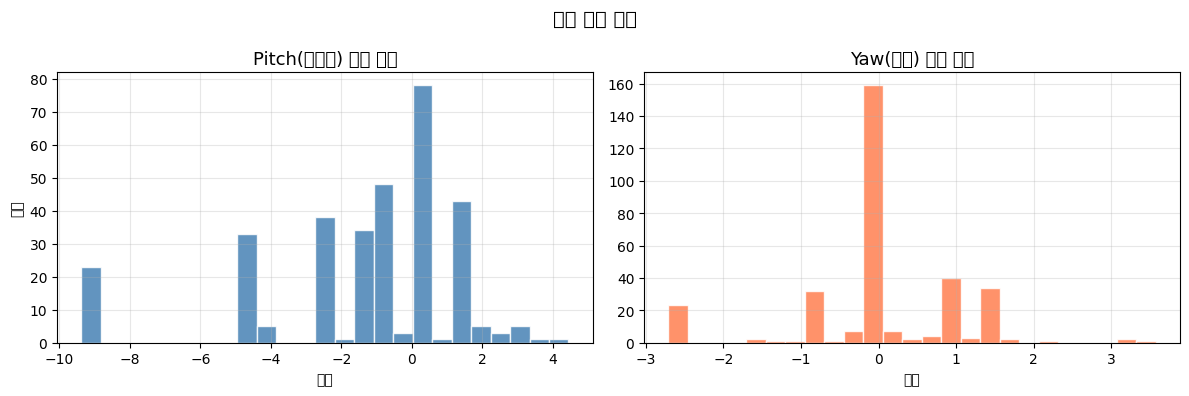

Pitch: min=-9.380  max=4.444  평균=-1.393
Yaw  : min=-2.709  max=3.573  평균=0.005


In [6]:
# 이미지와 JSON 파일 쌍 수집
image_files = sorted([f for f in IMAGE_DIR.iterdir() if f.suffix == '.png'])
paired_data = []
for img_path in image_files:
    json_path = LABEL_DIR / (img_path.stem + '.json')
    if json_path.exists():
        paired_data.append((img_path, json_path))

print(f"총 이미지: {len(image_files)}장")
print(f"JSON 쌍 맞는 데이터: {len(paired_data)}쌍")

# pitch/yaw 분포 확인
all_pitches = [load_label(j)[0] for _, j in paired_data]
all_yaws    = [load_label(j)[1] for _, j in paired_data]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(all_pitches, bins=25, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Pitch(위아래) 각도 분포', fontsize=13)
axes[0].set_xlabel('각도')
axes[0].set_ylabel('빈도')
axes[0].grid(True, alpha=0.3)

axes[1].hist(all_yaws, bins=25, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Yaw(좌우) 각도 분포', fontsize=13)
axes[1].set_xlabel('각도')
axes[1].grid(True, alpha=0.3)

plt.suptitle('라벨 분포 확인', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'label_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Pitch: min={min(all_pitches):.3f}  max={max(all_pitches):.3f}  평균={np.mean(all_pitches):.3f}")
print(f"Yaw  : min={min(all_yaws):.3f}  max={max(all_yaws):.3f}  평균={np.mean(all_yaws):.3f}")

## 6. 🤖 MediaPipe 랜드마크 추출 + 캐싱

전체 이미지에서 한 번만 랜드마크를 추출하고 파일로 저장합니다.  
다음에 다시 실행할 때는 저장된 캐시를 불러와서 시간을 아낍니다.

In [7]:
# 캐시 파일이 있으면 불러오고, 없으면 새로 추출
if CACHE_FILE.exists():
    print(f"캐시 파일 발견: {CACHE_FILE}")
    print("랜드마크 캐시를 불러옵니다... (빠름)")
    with open(CACHE_FILE, 'rb') as f:
        cache = pickle.load(f)
    print(f"캐시 로드 완료: {len(cache)}개")
else:
    print("캐시 없음 → MediaPipe로 랜드마크 추출 시작... (느림, 1회만)")
    cache = {}  # {이미지파일명: 랜드마크 배열}
    
    # FaceLandmarker는 with 문으로 사용 (자동 정리)
    with FaceLandmarker.create_from_options(mp_options) as face_landmarker:
        for img_path, _ in tqdm(paired_data, desc="랜드마크 추출"):
            landmarks = extract_landmarks(img_path, face_landmarker)
            cache[img_path.name] = landmarks  # None이면 감지 실패
    
    # 캐시 저장
    with open(CACHE_FILE, 'wb') as f:
        pickle.dump(cache, f)
    print(f"캐시 저장 완료: {CACHE_FILE}")

# 추출 결과 통계
success = sum(1 for v in cache.values() if v is not None)
failed  = len(cache) - success
print(f"\n📊 추출 결과:")
print(f"  성공: {success}장")
print(f"  실패 (얼굴 미감지): {failed}장")
print(f"  성공률: {success/len(cache)*100:.1f}%")

# 성공한 데이터만 사용
valid_pairs = [
    (img_path, json_path)
    for img_path, json_path in paired_data
    if cache.get(img_path.name) is not None
]
print(f"  학습에 사용할 데이터: {len(valid_pairs)}장")

캐시 없음 → MediaPipe로 랜드마크 추출 시작... (느림, 1회만)


랜드마크 추출: 100%|██████████| 322/322 [00:11<00:00, 28.12it/s]

캐시 저장 완료: landmark_cache.pkl

📊 추출 결과:
  성공: 322장
  실패 (얼굴 미감지): 0장
  성공률: 100.0%
  학습에 사용할 데이터: 322장


## 7. 🔬 랜드마크 샘플 시각화

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_92016\3185872190.py:42: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_92016\3185872190.py:42: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_92016\3185872190.py:42: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_92016\3185872190.py:42: UserWarning: Glyph 53469 (\N{HANGUL SYLLABLE TAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_92016\3185872190.py:42: UserWarning: Glyph 47004 (\N{HANGUL SYLLABLE RAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_92016\3185872190.py:42: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing f

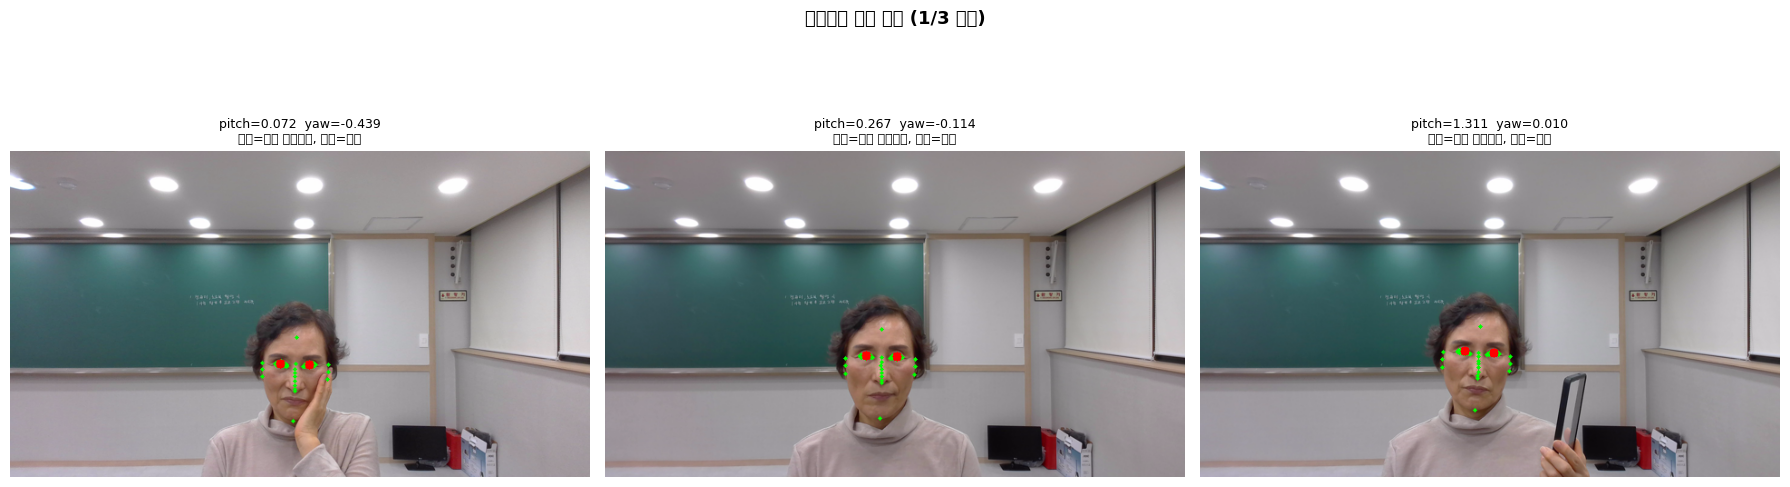

In [8]:
# 샘플 이미지에 랜드마크 찍어서 시각화
import cv2

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sample_indices = [0, len(valid_pairs)//3, len(valid_pairs)*2//3]

with FaceLandmarker.create_from_options(mp_options) as face_landmarker:
    for ax, idx in zip(axes, sample_indices):
        img_path, json_path = valid_pairs[idx]
        pitch, yaw = load_label(json_path)
        
        # 이미지 불러오기 (1920×1080이라 1/3로 축소 표시)
        img_pil = Image.open(img_path).convert('RGB')
        scale = 3
        small = img_pil.resize((img_pil.width // scale, img_pil.height // scale))
        img_np = np.array(small)
        H, W = img_np.shape[:2]
        
        # MediaPipe로 랜드마크 감지
        mp_img = mp.Image.create_from_file(str(img_path))
        result = face_landmarker.detect(mp_img)
        
        if result.face_landmarks:
            lm = result.face_landmarks[0]
            # 선택한 랜드마크를 점으로 표시
            for i in ALL_LANDMARK_IDX:
                px = int(lm[i].x * W)
                py = int(lm[i].y * H)
                cv2.circle(img_np, (px, py), 2, (0, 255, 0), -1)
            
            # 홍채 중심은 빨간색으로 강조
            for i in [468, 473]:
                px = int(lm[i].x * W)
                py = int(lm[i].y * H)
                cv2.circle(img_np, (px, py), 5, (255, 0, 0), -1)
        
        ax.imshow(img_np)
        ax.set_title(f'pitch={pitch:.3f}  yaw={yaw:.3f}\n초록=선택 랜드마크, 빨강=홍채', fontsize=9)
        ax.axis('off')

plt.suptitle('랜드마크 추출 확인 (1/3 축소)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'landmark_visualization.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. 📦 PyTorch 데이터셋 클래스 정의

In [9]:
class GazeLandmarkDataset(Dataset):
    """
    MediaPipe 랜드마크 → pitch/yaw 데이터셋
    
    이미지 대신 미리 추출해둔 랜드마크 좌표를 입력으로 사용합니다.
    덕분에 학습이 매우 빠르고 모델도 가볍습니다.
    """
    
    def __init__(self, data_pairs, cache, augment=False):
        """
        data_pairs : [(img_path, json_path), ...]
        cache      : {이미지파일명: 랜드마크 배열} 딕셔너리
        augment    : True면 학습용 데이터 증강 적용
        """
        self.data_pairs = data_pairs
        self.cache      = cache
        self.augment    = augment
    
    def __len__(self):
        return len(self.data_pairs)
    
    def __getitem__(self, idx):
        img_path, json_path = self.data_pairs[idx]
        
        # ── 1. 미리 추출한 랜드마크 불러오기 ───────────────────
        landmarks = self.cache[img_path.name].copy()  # [174]
        
        # ── 2. 데이터 증강 (학습 때만) ──────────────────────────
        if self.augment:
            # 미세한 가우시안 노이즈 추가
            # (실제 카메라 노이즈나 MediaPipe 오차를 시뮬레이션)
            noise = np.random.normal(0, 0.005, size=landmarks.shape).astype(np.float32)
            landmarks = landmarks + noise
            
            # 좌우 반전 (랜드마크 x좌표만 뒤집고, yaw도 반전)
            # → 왼쪽을 보는 데이터로 오른쪽 보는 데이터도 학습
            if np.random.random() < 0.5:
                landmarks = self._flip_landmarks(landmarks)
                pitch, yaw = load_label(json_path)
                yaw = -yaw  # 좌우 반전이므로 yaw 부호도 반전
                return (
                    torch.tensor(landmarks, dtype=torch.float32),
                    torch.tensor([pitch, yaw], dtype=torch.float32)
                )
        
        # ── 3. 라벨 불러오기 ────────────────────────────────────
        pitch, yaw = load_label(json_path)
        
        return (
            torch.tensor(landmarks, dtype=torch.float32),    # 입력: [174]
            torch.tensor([pitch, yaw], dtype=torch.float32)  # 정답: [2]
        )
    
    def _flip_landmarks(self, landmarks):
        """
        좌우 반전: x 좌표의 부호를 뒤집습니다.
        landmarks는 코 끝 기준으로 정규화되어 있으므로
        x 좌표만 부호 반전하면 됩니다.
        """
        flipped = landmarks.reshape(-1, 3).copy()  # [58, 3]
        flipped[:, 0] = -flipped[:, 0]             # x만 반전
        return flipped.flatten()


# 동작 확인
test_dataset = GazeLandmarkDataset(valid_pairs[:5], cache, augment=False)
lm, label = test_dataset[0]
print(f"랜드마크 텐서 크기: {lm.shape}")
print(f"라벨 텐서: {label}  (pitch={label[0].item():.3f}, yaw={label[1].item():.3f})")
print(f"랜드마크 값 범위: [{lm.min().item():.3f}, {lm.max().item():.3f}]")

랜드마크 텐서 크기: torch.Size([174])
라벨 텐서: tensor([ 0.0718, -0.4389])  (pitch=0.072, yaw=-0.439)
랜드마크 값 범위: [-2.978, 2.215]


## 9. 🔄 데이터 분할 + DataLoader 생성

In [15]:
# 학습 / 검증 분할 (8:2)
train_pairs, val_pairs = train_test_split(
    valid_pairs,
    train_size=TRAIN_RATIO,
    random_state=RANDOM_SEED,
    shuffle=True
)

# 데이터셋 생성
train_dataset = GazeLandmarkDataset(train_pairs, cache, augment=True)   # 증강 O
val_dataset   = GazeLandmarkDataset(val_pairs,   cache, augment=False)  # 증강 X

# DataLoader 생성
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    drop_last=True   # ← 마지막 배치가 1개일 때 BatchNorm 오류 방지
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    drop_last=False  # 검증은 모든 샘플 사용
)

print(f"학습 데이터: {len(train_dataset)}장  →  {len(train_loader)}배치")
print(f"검증 데이터: {len(val_dataset)}장   →  {len(val_loader)}배치")
print(f"배치 크기: {BATCH_SIZE}")

학습 데이터: 257장  →  8배치
검증 데이터: 65장   →  3배치
배치 크기: 32


## 10. 🧠 모델 구조 정의

```
랜드마크 좌표 [174]
      ↓
  FC(174→512) + BatchNorm + GELU + Dropout
      ↓  잔차 연결(Residual) 포함
  FC(512→256) + BatchNorm + GELU + Dropout  
      ↓
  FC(256→128) + BatchNorm + GELU + Dropout
      ↓
  FC(128→2)
      ↓
  [pitch, yaw] 예측값
```

**잔차 연결(Residual Connection)**: 깊은 네트워크에서 기울기 소실을 방지합니다.  
**GELU 활성화**: ReLU보다 부드러운 활성화 함수 (Transformer에서도 사용).

In [11]:
class ResidualBlock(nn.Module):
    """
    잔차 블록 (Residual Block)
    
    입력을 두 갈래로 나눠서:
    - 한 쪽은 FC 레이어를 통과
    - 다른 쪽은 그대로 전달 (skip connection)
    두 결과를 더해서 출력합니다.
    → 학습이 더 안정적이고 깊은 네트워크를 만들 수 있습니다.
    """
    def __init__(self, dim, dropout):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.gelu = nn.GELU()
    
    def forward(self, x):
        # 입력 + 변환 결과를 더해서 반환 (잔차 연결)
        return self.gelu(x + self.block(x))


class GazeMLP(nn.Module):
    """
    랜드마크 좌표 → pitch/yaw 회귀 모델
    
    - 입력: 정규화된 랜드마크 좌표 [174]
    - 출력: [pitch, yaw] 각도 [2]
    - ONNX 내보내기에 최적화된 단순한 구조
    """
    
    def __init__(self, input_dim, hidden_dims, dropout=0.3):
        super().__init__()
        
        layers = []
        prev_dim = input_dim
        
        for i, hidden_dim in enumerate(hidden_dims):
            # 일반 선형 레이어 (크기 조정)
            layers += [
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.GELU(),
                nn.Dropout(dropout),
            ]
            # 같은 크기끼리는 잔차 블록 추가
            if i < len(hidden_dims) - 1:
                layers.append(ResidualBlock(hidden_dim, dropout))
            
            prev_dim = hidden_dim
        
        self.features = nn.Sequential(*layers)
        
        # 최종 출력: pitch, yaw 두 개
        self.head = nn.Linear(prev_dim, 2)
    
    def forward(self, x):
        """
        x: [배치크기, 174]  →  출력: [배치크기, 2]  (pitch, yaw)
        """
        features = self.features(x)
        return self.head(features)


# 모델 생성
model = GazeMLP(
    input_dim=INPUT_DIM,         # 174 (58개 랜드마크 × 3)
    hidden_dims=HIDDEN_DIMS,     # [512, 256, 128]
    dropout=DROPOUT              # 0.3
).to(device)

# 파라미터 수 확인
total_params = sum(p.numel() for p in model.parameters())
print(f"모델 파라미터 수: {total_params:,}  (~{total_params/1e6:.2f}M)")

# 순전파 테스트
dummy = torch.randn(4, INPUT_DIM).to(device)
output = model(dummy)
print(f"순전파 테스트: 입력 {dummy.shape} → 출력 {output.shape}")
print(f"  예측 pitch: {output[:, 0].detach().cpu().numpy()}")
print(f"  예측 yaw  : {output[:, 1].detach().cpu().numpy()}")

모델 파라미터 수: 915,842  (~0.92M)
순전파 테스트: 입력 torch.Size([4, 174]) → 출력 torch.Size([4, 2])
  예측 pitch: [-0.40931106 -0.71964264 -0.7507512   0.36284077]
  예측 yaw  : [-0.53254145 -0.0319291   0.16697317  0.09380297]


## 11. 📉 손실 함수 + 옵티마이저 + 스케줄러

**Smooth L1 Loss (Huber Loss)**: 각도 회귀에 적합합니다.
- 오차가 작을 때 → MSE처럼 (부드럽게 수렴)
- 오차가 클 때 → MAE처럼 (이상값에 강건)

In [12]:
# ── 손실 함수 ─────────────────────────────────────────────────────
# SmoothL1Loss = Huber Loss: 이상값(outlier)에 강건한 회귀 손실
criterion = nn.SmoothL1Loss(beta=0.5)  # beta: 전환 기준 오차

# ── 옵티마이저 (AdamW) ────────────────────────────────────────────
# AdamW = Adam + 올바른 Weight Decay (L2 정규화)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# ── 학습률 스케줄러 (OneCycleLR) ──────────────────────────────────
# 처음엔 학습률을 올렸다가 서서히 낮추는 방식
# 짧은 학습에서도 좋은 수렴을 보여줌
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE,
    steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS,
    pct_start=0.1,      # 전체의 10%까지 학습률 올리기
    div_factor=10,      # 시작 학습률 = max_lr / 10
    final_div_factor=100  # 최종 학습률 = max_lr / 1000
)

print(f"손실 함수: SmoothL1Loss (beta=0.5)")
print(f"옵티마이저: AdamW (lr={LEARNING_RATE}, wd={WEIGHT_DECAY})")
print(f"스케줄러: OneCycleLR (max_lr={LEARNING_RATE})")

손실 함수: SmoothL1Loss (beta=0.5)
옵티마이저: AdamW (lr=0.0003, wd=0.0001)
스케줄러: OneCycleLR (max_lr=0.0003)


## 12. 🚀 학습 루프 (MLflow 연동)

MLflow UI 보기: 터미널에서 `mlflow ui` 실행 → http://127.0.0.1:5000

In [13]:
def train_one_epoch(model, loader, optimizer, scheduler, criterion, device):
    """한 에포크 학습. 평균 손실과 MAE(각도 오차)를 반환합니다."""
    model.train()  # 학습 모드 (Dropout 활성화)
    total_loss, total_mae_p, total_mae_y = 0.0, 0.0, 0.0
    
    for landmarks, labels in loader:
        landmarks = landmarks.to(device)   # [B, 174]
        labels    = labels.to(device)      # [B, 2]
        
        # 순전파
        preds = model(landmarks)           # [B, 2]
        loss  = criterion(preds, labels)   # 손실 계산
        
        # 역전파
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # 기울기 폭발 방지
        optimizer.step()
        scheduler.step()  # OneCycleLR은 배치마다 업데이트
        
        # 각도별 MAE (평균 절대 오차) 계산
        with torch.no_grad():
            mae = (preds - labels).abs()
            total_loss  += loss.item()
            total_mae_p += mae[:, 0].mean().item()  # pitch 오차
            total_mae_y += mae[:, 1].mean().item()  # yaw 오차
    
    n = len(loader)
    return total_loss / n, total_mae_p / n, total_mae_y / n


@torch.no_grad()  # 검증 때는 기울기 불필요 → 메모리 절약
def validate(model, loader, criterion, device):
    """검증 데이터로 성능 평가. 평균 손실과 MAE를 반환합니다."""
    model.eval()  # 평가 모드 (Dropout 비활성화)
    total_loss, total_mae_p, total_mae_y = 0.0, 0.0, 0.0
    
    for landmarks, labels in loader:
        landmarks = landmarks.to(device)
        labels    = labels.to(device)
        
        preds = model(landmarks)
        loss  = criterion(preds, labels)
        mae   = (preds - labels).abs()
        
        total_loss  += loss.item()
        total_mae_p += mae[:, 0].mean().item()
        total_mae_y += mae[:, 1].mean().item()
    
    n = len(loader)
    return total_loss / n, total_mae_p / n, total_mae_y / n


print("학습/검증 함수 정의 완료")

학습/검증 함수 정의 완료


In [16]:
# ── MLflow 실험 설정 ──────────────────────────────────────────────
mlflow.set_experiment("GazeLandmarkMLP")

# 학습 기록 저장용
history = {
    'train_loss': [], 'val_loss': [],
    'train_mae_pitch': [], 'val_mae_pitch': [],
    'train_mae_yaw':   [], 'val_mae_yaw':   [],
}

best_val_loss = float('inf')
best_epoch    = 0

with mlflow.start_run(run_name=RUN_NAME) as run:
    
    # 설정값 기록
    mlflow.log_params({
        "input_dim":      INPUT_DIM,
        "hidden_dims":    str(HIDDEN_DIMS),
        "dropout":        DROPOUT,
        "batch_size":     BATCH_SIZE,
        "num_epochs":     NUM_EPOCHS,
        "learning_rate":  LEARNING_RATE,
        "weight_decay":   WEIGHT_DECAY,
        "train_samples":  len(train_dataset),
        "val_samples":    len(val_dataset),
        "total_params":   total_params,
        "landmark_count": len(ALL_LANDMARK_IDX),
        "save_dir":       str(SAVE_DIR),
    })
    
    print(f"{'='*65}")
    print(f"  {RUN_NAME}")
    print(f"  MLflow Run ID: {run.info.run_id[:8]}...")
    print(f"  학습 {len(train_dataset)}장  |  검증 {len(val_dataset)}장")
    print(f"{'='*65}")
    
    for epoch in range(1, NUM_EPOCHS + 1):
        
        train_loss, train_mae_p, train_mae_y = train_one_epoch(
            model, train_loader, optimizer, scheduler, criterion, device
        )
        val_loss, val_mae_p, val_mae_y = validate(
            model, val_loader, criterion, device
        )
        
        current_lr = optimizer.param_groups[0]['lr']
        
        # 기록 저장
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_mae_pitch'].append(train_mae_p)
        history['val_mae_pitch'].append(val_mae_p)
        history['train_mae_yaw'].append(train_mae_y)
        history['val_mae_yaw'].append(val_mae_y)
        
        # MLflow에 지표 기록
        mlflow.log_metrics({
            "train_loss":      train_loss,
            "val_loss":        val_loss,
            "train_mae_pitch": train_mae_p,
            "val_mae_pitch":   val_mae_p,
            "train_mae_yaw":   train_mae_y,
            "val_mae_yaw":     val_mae_y,
            "learning_rate":   current_lr,
        }, step=epoch)
        
        # 10 에포크마다 출력
        if epoch % 10 == 0 or epoch == 1:
            print(f"[{epoch:3d}/{NUM_EPOCHS}] "
                  f"학습손실: {train_loss:.4f} │ "
                  f"검증손실: {val_loss:.4f} │ "
                  f"pitch MAE: {val_mae_p:.4f} │ "
                  f"yaw MAE: {val_mae_y:.4f}")
        
        # 최고 모델 저장
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch    = epoch
            
            torch.save({
                'epoch':      epoch,
                'run_name':   RUN_NAME,
                'model_state_dict': model.state_dict(),
                'val_loss':      val_loss,
                'val_mae_pitch': val_mae_p,
                'val_mae_yaw':   val_mae_y,
                # 나중에 모델 재현에 필요한 설정값도 저장
                'config': {
                    'input_dim':   INPUT_DIM,
                    'hidden_dims': HIDDEN_DIMS,
                    'dropout':     DROPOUT,
                    'landmark_idx': ALL_LANDMARK_IDX,
                    'nose_tip_idx': NOSE_TIP_IDX,
                    'l_iris_idx':   L_IRIS_CTR,
                    'r_iris_idx':   R_IRIS_CTR,
                }
            }, SAVE_DIR / 'best_model.pth')
    
    # 최종 요약 기록
    mlflow.log_metrics({
        "best_val_loss":      best_val_loss,
        "best_epoch":         best_epoch,
        "best_val_mae_pitch": history['val_mae_pitch'][best_epoch - 1],
        "best_val_mae_yaw":   history['val_mae_yaw'][best_epoch - 1],
    })
    
    # 모델 파일을 MLflow에도 등록
    mlflow.log_artifact(str(SAVE_DIR / 'best_model.pth'), artifact_path="model")
    
    print(f"\n{'='*65}")
    print(f"  학습 완료!")
    print(f"  최고 성능: epoch {best_epoch}  |  검증손실 {best_val_loss:.4f}")
    print(f"  pitch MAE: {history['val_mae_pitch'][best_epoch-1]:.4f}")
    print(f"  yaw MAE  : {history['val_mae_yaw'][best_epoch-1]:.4f}")
    print(f"  저장 폴더: {SAVE_DIR}")
    print(f"{'='*65}")

  run_003_20260305_0623_ep200
  MLflow Run ID: 4119e325...
  학습 257장  |  검증 65장
[  1/200] 학습손실: 1.2789 │ 검증손실: 1.7128 │ pitch MAE: 2.9128 │ yaw MAE: 0.9369
[ 10/200] 학습손실: 1.0898 │ 검증손실: 1.3477 │ pitch MAE: 2.3893 │ yaw MAE: 0.7557
[ 20/200] 학습손실: 0.8742 │ 검증손실: 0.7629 │ pitch MAE: 1.2875 │ yaw MAE: 0.6536
[ 30/200] 학습손실: 0.7129 │ 검증손실: 0.9202 │ pitch MAE: 1.7499 │ yaw MAE: 0.5427
[ 40/200] 학습손실: 0.6846 │ 검증손실: 0.4369 │ pitch MAE: 0.8271 │ yaw MAE: 0.3718
[ 50/200] 학습손실: 0.6579 │ 검증손실: 0.6643 │ pitch MAE: 0.5811 │ yaw MAE: 1.0702
[ 60/200] 학습손실: 0.6019 │ 검증손실: 0.3513 │ pitch MAE: 0.6397 │ yaw MAE: 0.3663
[ 70/200] 학습손실: 0.5615 │ 검증손실: 0.3748 │ pitch MAE: 0.8269 │ yaw MAE: 0.2497
[ 80/200] 학습손실: 0.5428 │ 검증손실: 0.4308 │ pitch MAE: 0.9294 │ yaw MAE: 0.2148
[ 90/200] 학습손실: 0.5105 │ 검증손실: 0.3125 │ pitch MAE: 0.5783 │ yaw MAE: 0.3159
[100/200] 학습손실: 0.5090 │ 검증손실: 0.2017 │ pitch MAE: 0.3882 │ yaw MAE: 0.2885
[110/200] 학습손실: 0.4693 │ 검증손실: 0.2960 │ pitch MAE: 0.5597 │ yaw MAE: 0.3458
[120/200

## 13. 📊 학습 결과 시각화

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_92016\1927064400.py:36: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_92016\1927064400.py:36: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_92016\1927064400.py:36: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_92016\1927064400.py:36: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_92016\1927064400.py:36: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_92016\1927064400.py:36: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from f

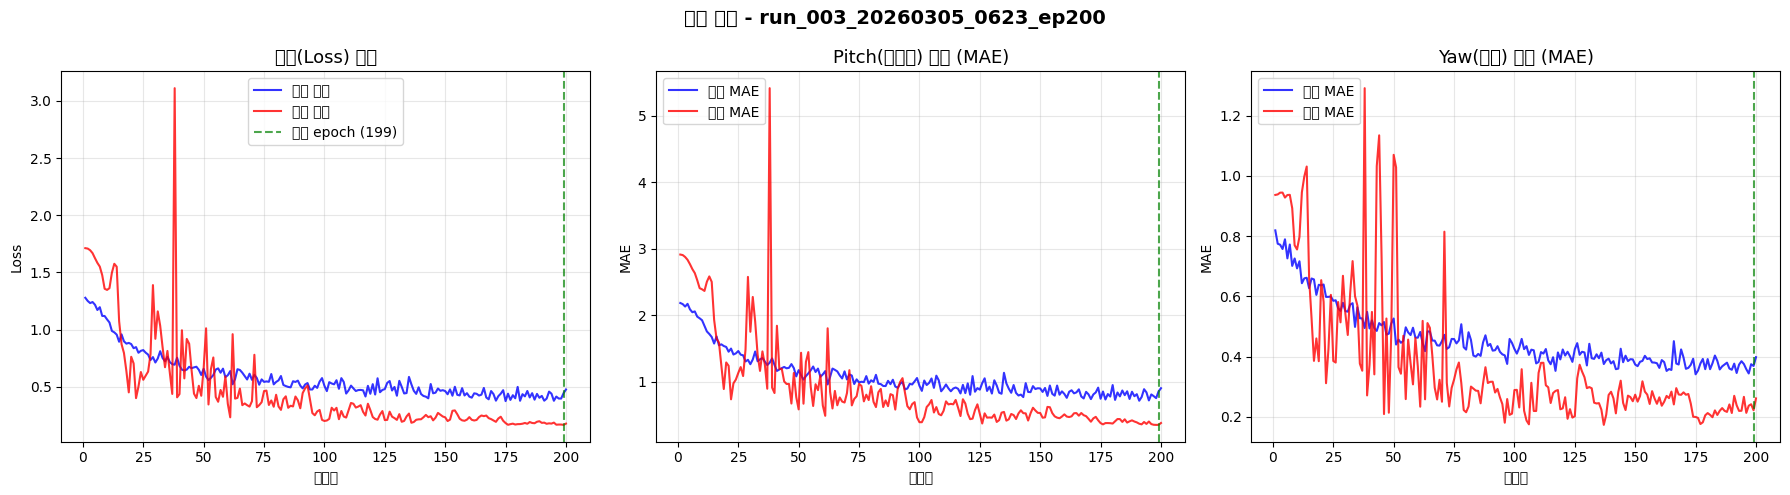

최고 성능 (epoch 199):
  Loss      : 0.1674
  Pitch MAE : 0.3476
  Yaw MAE   : 0.2215


In [17]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 손실 곡선
axes[0].plot(epochs_range, history['train_loss'], 'b-', linewidth=1.5, label='학습 손실', alpha=0.8)
axes[0].plot(epochs_range, history['val_loss'],   'r-', linewidth=1.5, label='검증 손실', alpha=0.8)
axes[0].axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'최고 epoch ({best_epoch})')
axes[0].set_title('손실(Loss) 곡선', fontsize=13)
axes[0].set_xlabel('에포크')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Pitch MAE
axes[1].plot(epochs_range, history['train_mae_pitch'], 'b-', linewidth=1.5, label='학습 MAE', alpha=0.8)
axes[1].plot(epochs_range, history['val_mae_pitch'],   'r-', linewidth=1.5, label='검증 MAE', alpha=0.8)
axes[1].axvline(best_epoch, color='green', linestyle='--', alpha=0.7)
axes[1].set_title('Pitch(위아래) 오차 (MAE)', fontsize=13)
axes[1].set_xlabel('에포크')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Yaw MAE
axes[2].plot(epochs_range, history['train_mae_yaw'], 'b-', linewidth=1.5, label='학습 MAE', alpha=0.8)
axes[2].plot(epochs_range, history['val_mae_yaw'],   'r-', linewidth=1.5, label='검증 MAE', alpha=0.8)
axes[2].axvline(best_epoch, color='green', linestyle='--', alpha=0.7)
axes[2].set_title('Yaw(좌우) 오차 (MAE)', fontsize=13)
axes[2].set_xlabel('에포크')
axes[2].set_ylabel('MAE')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'학습 결과 - {RUN_NAME}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'training_curves.png', dpi=120, bbox_inches='tight')

# MLflow에 그래프 등록
with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_artifact(str(SAVE_DIR / 'training_curves.png'), artifact_path="plots")

plt.show()

print(f"최고 성능 (epoch {best_epoch}):")
print(f"  Loss      : {best_val_loss:.4f}")
print(f"  Pitch MAE : {history['val_mae_pitch'][best_epoch-1]:.4f}")
print(f"  Yaw MAE   : {history['val_mae_yaw'][best_epoch-1]:.4f}")

## 14. 🔍 검증 샘플 예측 비교

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_92016\1036417849.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(SAVE_DIR / 'best_model.pth', map_loc

최고 모델 불러오기 완료 (epoch 199, val_loss=0.1674)


C:\Users\SSAFY\AppData\Local\Temp\ipykernel_92016\1036417849.py:42: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_92016\1036417849.py:42: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_92016\1036417849.py:42: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_92016\1036417849.py:42: UserWarning: Glyph 50500 (\N{HANGUL SYLLABLE A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_92016\1036417849.py:42: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_92016\1036417849.py:42: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from fon

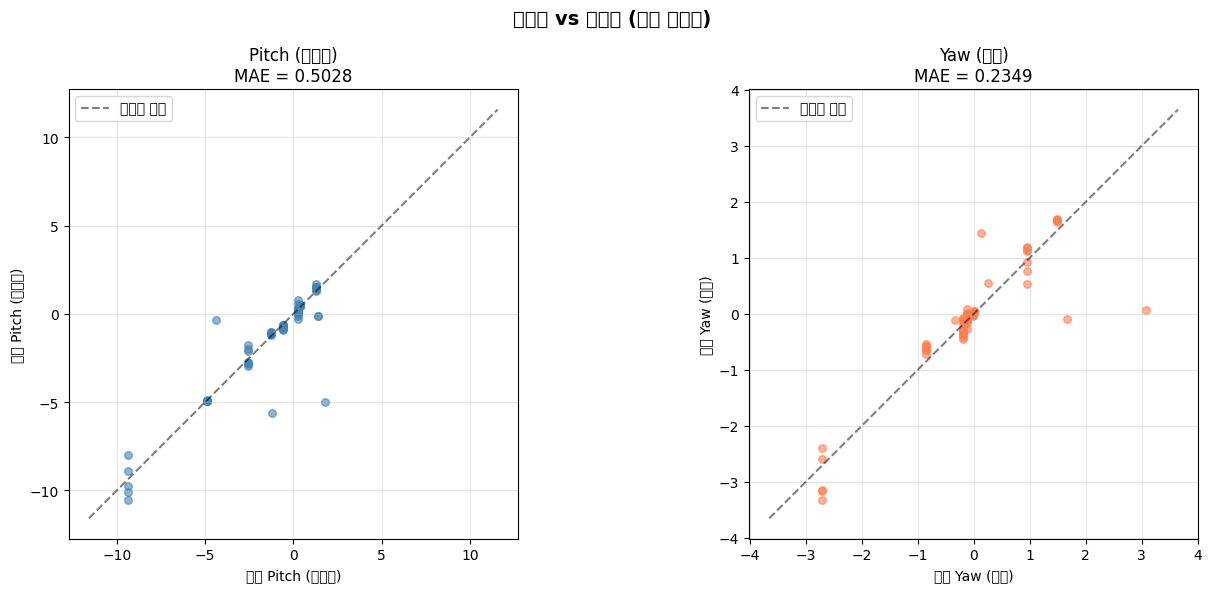

In [18]:
# 최고 모델 불러오기
checkpoint = torch.load(SAVE_DIR / 'best_model.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"최고 모델 불러오기 완료 (epoch {checkpoint['epoch']}, val_loss={checkpoint['val_loss']:.4f})")

# 검증 데이터 전체 예측
all_preds  = []
all_labels = []

with torch.no_grad():
    for landmarks, labels in val_loader:
        preds = model(landmarks.to(device)).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds  = torch.cat(all_preds).numpy()   # [N, 2]
all_labels = torch.cat(all_labels).numpy()  # [N, 2]

# 산점도: 예측값 vs 실제값
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, title in zip(axes, [0, 1], ['Pitch (위아래)', 'Yaw (좌우)']):
    true = all_labels[:, col]
    pred = all_preds[:, col]
    mae  = np.abs(true - pred).mean()
    
    ax.scatter(true, pred, alpha=0.6, s=30, color='steelblue' if col==0 else 'coral')
    
    # 완벽한 예측이면 y=x 직선
    lim = max(abs(true).max(), abs(pred).max()) * 1.1
    ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=1.5, alpha=0.5, label='완벽한 예측')
    
    ax.set_xlabel(f'실제 {title}')
    ax.set_ylabel(f'예측 {title}')
    ax.set_title(f'{title}\nMAE = {mae:.4f}', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

plt.suptitle('예측값 vs 실제값 (검증 데이터)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'prediction_scatter.png', dpi=120, bbox_inches='tight')

with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_artifact(str(SAVE_DIR / 'prediction_scatter.png'), artifact_path="plots")

plt.show()

## 15. 💾 ONNX 내보내기

나중에 **MediaPipe.js + ONNX.js**로 브라우저에서 직접 실행할 수 있습니다.

```
브라우저 실행 흐름:
카메라 영상 → MediaPipe.js(랜드마크 추출) → 정규화 → ONNX.js(이 모델) → pitch/yaw
```

In [19]:
model.eval()
model.cpu()  # ONNX 내보내기는 CPU에서

# 더미 입력 (배치 1개, 랜드마크 174개)
dummy_input = torch.randn(1, INPUT_DIM)
onnx_path   = SAVE_DIR / 'gaze_landmark_mlp.onnx'

torch.onnx.export(
    model,
    dummy_input,
    str(onnx_path),
    export_params=True,                    # 학습된 가중치 포함
    opset_version=12,                      # ONNX 연산 버전 (브라우저 호환)
    do_constant_folding=True,              # 상수 연산 최적화
    input_names=['landmarks'],             # 입력 이름 (JS에서 이 이름으로 접근)
    output_names=['gaze'],                 # 출력 이름: [pitch, yaw]
    dynamic_axes={
        'landmarks': {0: 'batch_size'},    # 배치 크기 가변 허용
        'gaze':      {0: 'batch_size'},
    }
)

onnx_size_kb = onnx_path.stat().st_size / 1024
print(f"ONNX 내보내기 완료!")
print(f"파일 크기: {onnx_size_kb:.1f} KB  (ResNet50 기반 모델은 ~90MB였음)")
print(f"저장 위치: {onnx_path}")

# MLflow에 ONNX 파일도 등록
with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_artifact(str(onnx_path), artifact_path="onnx")
    print("MLflow ONNX 등록 완료")

# 최종 저장 파일 목록 출력
print(f"\n📂 {SAVE_DIR.name} 저장 파일:")
for f in sorted(SAVE_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<40} {size_kb:>8.1f} KB")

ONNX 내보내기 완료!
파일 크기: 3610.3 KB  (ResNet50 기반 모델은 ~90MB였음)
저장 위치: runs\run_003_20260305_0623_ep200\gaze_landmark_mlp.onnx
MLflow ONNX 등록 완료

📂 run_003_20260305_0623_ep200 저장 파일:
  best_model.pth                             3614.0 KB
  gaze_landmark_mlp.onnx                     3610.3 KB
  label_distribution.png                       26.6 KB
  landmark_visualization.png                  764.0 KB
  prediction_scatter.png                       52.7 KB
  training_curves.png                         142.6 KB


---
## 📌 다음 단계 안내

### MLflow로 실험 비교하기
```bash
cd "c:/Users/SSAFY/Desktop/AI/eye_tracking/landmark_gaze"
mlflow ui
# → http://127.0.0.1:5000 에서 run별 지표 비교 가능
```

### 폴더 구조 (실행할 때마다 새 폴더)
```
landmark_gaze/
├── train_landmark.ipynb
├── face_landmarker.task
├── landmark_cache.pkl          ← 한 번 추출 후 재사용
├── mlruns/                     ← MLflow 기록
└── runs/
    ├── run_001_20260305_1030_ep200/   ← 1차 학습
    │   ├── best_model.pth             (PyTorch 모델)
    │   ├── gaze_landmark_mlp.onnx     (브라우저용 ONNX)
    │   ├── training_curves.png
    │   ├── prediction_scatter.png
    │   ├── landmark_visualization.png
    │   └── label_distribution.png
    ├── run_002_20260305_1200_ep300/   ← 2차 학습 (에포크 늘림)
    └── run_003_20260305_1400_ep200/   ← 3차 학습 (구조 변경)
```

### 다음에 다른 설정으로 실험할 때
**2번 셀 (`⚙️ 설정`)** 에서 수치만 바꾸고 처음부터 다시 실행:
```python
HIDDEN_DIMS = [1024, 512, 256, 128]  # 더 깊게
NUM_EPOCHS  = 300                    # 더 오래
DROPOUT     = 0.2                    # 드롭아웃 줄이기
```

### 브라우저 배포 계획
```
1. MediaPipe Face Landmarker (JS)  → 랜드마크 추출
2. 정규화 코드 (JS)               → 코 끝 기준, IOD 나누기  
3. ONNX.js 또는 onnxruntime-web   → 이 모델로 pitch/yaw 예측
4. 예측값 → 화면 좌표로 변환      → 마우스 커서 이동
```